# 🩺 MEDPREDICT: o fluxo completo, do CSV ao modelo

**Grupo 5 · Turma Fly · diversiData.** Este notebook pega TUDO que vocês já construíram (as 6 hipóteses, o confundimento do SMS que a Jacque destrinchou, a faxina da Tati, o ajuste de limiar) e coloca na ordem das **10 estações do aulão**, com cada passo explicado antes ("🔎 O que vamos fazer") e lido depois ("📖 Como ler"). Nada de novo caiu do céu: é o trabalho de vocês, agora com o fio que liga uma ponta à outra.

**A pergunta central:** *dá pra prever quais pacientes vão faltar à consulta, pra clínica agir antes (ligar, confirmar, remanejar a vaga)?*

**O alvo:** `Faltou` (1 = faltou, 0 = compareceu). É SIM ou NÃO: **trilha da classificação**.

## Créditos (o que veio de quem)

| Parte | Origem |
|---|---|
| Hipótese 1 (tempo de espera) | Tati |
| Hipótese 2 (faixa etária) | Tati e Jacque |
| Hipóteses 3 e 4 (SMS, bairros) e a descoberta das datas | Jacque |
| Faxina com registros removidos preservados | Tati |
| Comparação de modelos, limiar de decisão | grupo, consolidado |

## O mapa das 10 estações (o fio do projeto)

| # | Estação | No MedPredict |
|---|---|---|
| 1 | **Carregar** | O CSV do Kaggle (110 mil consultas de Vitória/ES, 2016) |
| 2 | **Parquet** | Checkpoints pra nunca reprocessar do zero |
| 3 | **Hipóteses** | As 6 de vocês, com afirmação + mecanismo + teste |
| 4 | **EDA** | O alvo 80/20, a sujeira que não é vazio, o confundimento do SMS |
| 5 | **Faxina fixa** | Datas, idade negativa, dias de espera, comorbidades (regras, não números) |
| 6 | **Separar** | Com stratify (o alvo é desbalanceado) |
| 7 | **Selecionar** | A mesa: quem ajuda a prever a falta? |
| 8 | **A régua** | Por que acurácia mente aqui e por que recall manda |
| 9 | **Modelos** | Baseline, logística, árvore, floresta, boosting |
| 10 | **Limiar, ajuste e salvar** | O dimmer da decisão, GridSearch, joblib, paciente novo |

> **A regra de ouro que vocês já tinham:** antes de cada passo, pergunte *"isso calcula um número a partir dos dados?"*. Se é regra fixa (corrigir tipo, remover erro de cadastro, fazer uma conta), pode vir antes de separar. Se aprende um número (mediana, escala, categorias), só no treino, dentro do Pipeline.

> **Dado é gente:** cada linha é uma pessoa que precisou de um médico. Uma falta prevista e evitada é uma vaga que atende alguém.


---
# Estação 0: preparar o ambiente


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

np.random.seed(42)
plt.rcParams.update({'figure.figsize':(7,4.2),'figure.dpi':110,'font.size':11,
    'axes.grid':True,'grid.alpha':0.22,'axes.spines.top':False,'axes.spines.right':False,
    'axes.titlesize':13,'axes.titleweight':'bold'})
TEAL='#1da67a'; TEAL_D='#0f6e52'; AMBER='#e8a020'; CORAL='#d8562e'; NAVY='#0d1b2a'; SKY='#3a9ad9'; PURPLE='#7b5ea7'
os.makedirs('dados', exist_ok=True)
print("Ambiente pronto. Pasta 'dados/' criada para os checkpoints.")

Ambiente pronto. Pasta 'dados/' criada para os checkpoints.


---
# Estação 1: CARREGAR (o código de vocês, Colab ou local)

**🔎 O que vamos fazer:** achar o CSV (na pasta do grupo no Drive OU na pasta do notebook), ler, e fazer o ritual: shape, head, info. Aqui só se OLHA.


In [3]:
CAMINHOS_POSSIVEIS = [
    Path("/content/drive/MyDrive/FLY - Diversos/Projeto TCC/Base de Dados - Planilha/KaggleV2-May-2016.csv"),
    Path("KaggleV2-May-2016.csv"),
]
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass   # fora do Colab, segue

caminho = next((p for p in CAMINHOS_POSSIVEIS if p.exists()), None)
if caminho is None:
    raise FileNotFoundError("CSV nao encontrado: coloque KaggleV2-May-2016.csv na pasta do notebook ou no Drive.")
base = pd.read_csv(caminho)
print("Base carregada de:", caminho)
print("Formato:", base.shape[0], "linhas x", base.shape[1], "colunas")
base.head()

Mounted at /content/drive
Base carregada de: /content/drive/MyDrive/FLY - Diversos/Projeto TCC/Base de Dados - Planilha/KaggleV2-May-2016.csv
Formato: 110527 linhas x 14 colunas


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


**📖 Como ler:** 110 mil consultas, 14 colunas, e o `info()` diz **zero vazios**. Isso NÃO significa base limpa: a sujeira daqui mora em valores inválidos (idade negativa, data trocada, `Handcap` que vai de 0 a 4 e não é sim/não). `PatientId` e `AppointmentID` são identificadores: não descrevem ninguém, saem na faxina. E as datas vieram como texto: viram data na faxina também.


---
# Estação 2: SALVAR EM PARQUET

**🔎 O que vamos fazer:** guardar a foto da base bruta. Cada estação vai deixar um checkpoint: se a sessão do Colab cair no meio, vocês recomeçam do último em vez do zero.


In [5]:
base.to_parquet('dados/01_bruto.parquet', index=False)
print(f"Checkpoint 01_bruto: {os.path.getsize('dados/01_bruto.parquet')/1024:.0f} KB (o CSV tinha {os.path.getsize(caminho)/1024:.0f} KB).")
print("Para recomecar de qualquer sessao: base = pd.read_parquet('dados/01_bruto.parquet')")

Checkpoint 01_bruto: 2658 KB (o CSV tinha 10488 KB).
Para recomecar de qualquer sessao: base = pd.read_parquet('dados/01_bruto.parquet')


---
# Estação 3: LEVANTAR HIPÓTESES (as 6 de vocês, formalizadas)

A receita: **afirmação + mecanismo (o porquê do mundo real) + teste**.

| # | Afirmação | Mecanismo | Teste |
|---|---|---|---|
| **H1** | Quanto maior a espera, mais falta | A necessidade passa, a pessoa esquece, resolve de outro jeito | Mediana de espera por grupo + Mann-Whitney |
| **H2** | Adolescentes e jovens faltam mais | Menos rotina de saúde, mais imprevistos | Taxa de falta por faixa etária + chi2 |
| **H3** | Quem recebe SMS falta menos | O lembrete combate o esquecimento | Taxa por SMS **dentro de cada faixa de espera** (cuidado com confundimento!) |
| **H4** | Alguns bairros faltam mais | Distância, transporte, condição socioeconômica | Taxa por bairro com mínimo de consultas |
| **H5** | Mulheres faltam mais que homens | (a testar: pode ser só que usam mais o serviço) | Taxa por sexo + chi2 |
| **H6** | Quem tem comorbidade falta menos | Acompanhamento contínuo, percepção de necessidade | Taxa por número de comorbidades |

Hipótese derrubada também é ciência: a H5 vai cair, e isso vale nota.


---
# Estação 4: EDA, o exame clínico (olhar sem consertar)

## Pergunta 1: como é o alvo?

**🔎 O que vamos fazer:** contar quem faltou e quem compareceu. Esse número decide DUAS coisas lá na frente: o `stratify` da separação e a régua (por que acurácia vai mentir).


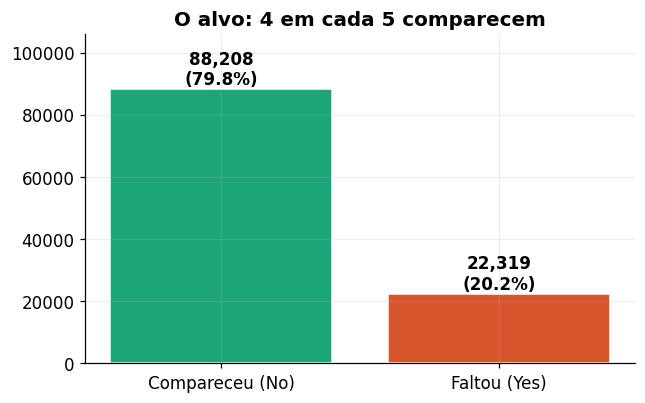

In [6]:
vc = base['No-show'].value_counts()
fig, ax = plt.subplots(figsize=(6,3.8))
ax.bar(['Compareceu (No)','Faltou (Yes)'], vc.values, color=[TEAL, CORAL], edgecolor='white')
for i, v in enumerate(vc.values): ax.text(i, v+1500, f'{v:,}\n({v/len(base)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('O alvo: 4 em cada 5 comparecem'); ax.set_ylim(0, vc.max()*1.2)
plt.tight_layout(); plt.show()

**📖 Como ler (guardem este número):** ~80% comparecem, ~20% faltam. **A armadilha da acurácia** nasce aqui: um modelo preguiçoso que chuta "vai comparecer" pra TODO MUNDO acerta 80% e nunca encontra UMA falta. É por isso que na Estação 8 a acurácia vai pro banco de reservas e o **recall** assume.

## Pergunta 2: o que está sujo? (a sujeira que não é vazio)


In [7]:
print("Linhas duplicadas:", base.duplicated().sum())
print("Vazios em toda a base:", int(base.isnull().sum().sum()))
print("\nIdade negativa (impossivel):", (base['Age'] < 0).sum(), "| idade maxima:", base['Age'].max())
print("\nHandcap NAO e sim/nao, e uma contagem de 0 a 4:")
print(base['Handcap'].value_counts().sort_index().to_string())

# A descoberta da Jacque: as datas
sched = pd.to_datetime(base['ScheduledDay']); appt = pd.to_datetime(base['AppointmentDay'])
print("\nConsulta 'antes' do agendamento comparando COM horario:", (sched > appt).sum(), " <- falso alarme!")
print("Consulta antes do agendamento comparando SO a data:   ", (sched.dt.normalize() > appt.dt.normalize()).sum(), " <- erro real")

Linhas duplicadas: 0
Vazios em toda a base: 0

Idade negativa (impossivel): 1 | idade maxima: 115

Handcap NAO e sim/nao, e uma contagem de 0 a 4:
Handcap
0    108286
1      2042
2       183
3        13
4         3

Consulta 'antes' do agendamento comparando COM horario: 38568  <- falso alarme!
Consulta antes do agendamento comparando SO a data:    5  <- erro real


**📖 Como ler:** a base engana quem olha rápido. Zero vazios, mas: 1 idade negativa, `Handcap` que é contagem (0 a 4), e a pegadinha das datas: `AppointmentDay` não guarda horário (fica 00:00), então 38 mil consultas "no passado" eram falso alarme; comparando só a data, sobram **5 erros reais**. Tudo isso vai pra lista da faxina, com regra fixa (não calcula número).

## Perguntas 3 e 4: as hipóteses, uma a uma

**🔎 O que vamos fazer:** criar as colunas de apoio SÓ pra olhar (a versão oficial nasce na faxina) e testar H1 a H6.


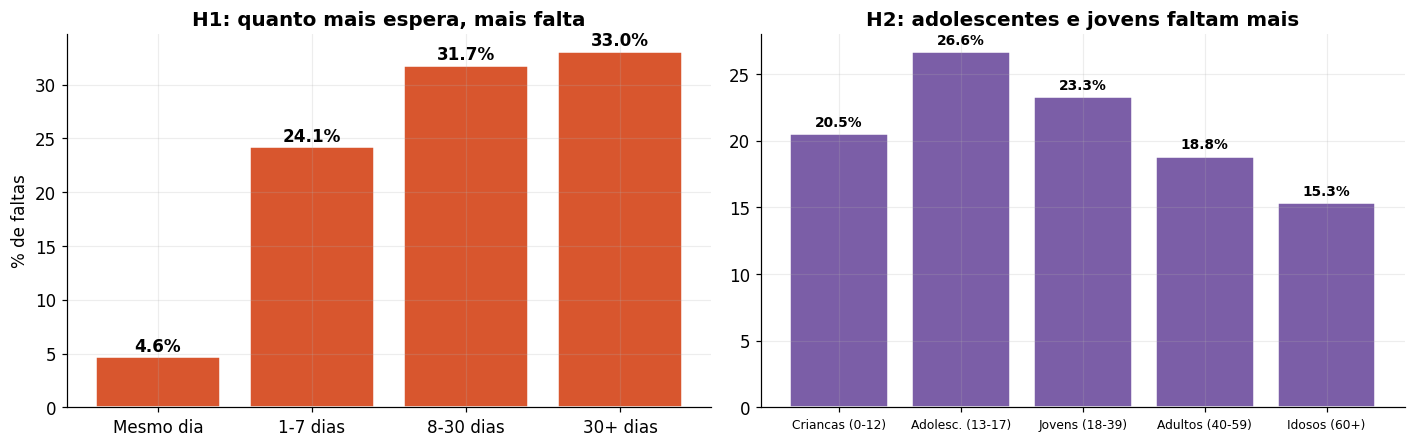

H1: mediana de espera: 2 dias (compareceu) vs 11 dias (faltou) | Mann-Whitney p = 0.0e+00 -> CONFIRMADA
H2: chi2 p = 2.3e-150, V de Cramer = 0.080 -> CONFIRMADA, mas efeito FRACO (p pequeno nao e efeito grande)


In [8]:
eda = base.copy()
eda['Faltou'] = (eda['No-show'] == 'Yes').astype(int)
eda['DiasEspera'] = (appt.dt.normalize() - sched.dt.normalize()).dt.days
eda = eda[(eda['DiasEspera'] >= 0) & (eda['Age'] >= 0)]
eda['FaixaEspera'] = pd.cut(eda['DiasEspera'], bins=[-1,0,7,30,400], labels=['Mesmo dia','1-7 dias','8-30 dias','30+ dias'])
eda['FaixaEtaria'] = pd.cut(eda['Age'], bins=[-1,12,17,39,59,200],
                            labels=['Criancas (0-12)','Adolesc. (13-17)','Jovens (18-39)','Adultos (40-59)','Idosos (60+)'])

fig, axes = plt.subplots(1, 2, figsize=(13,4.2))
t = eda.groupby('FaixaEspera', observed=True)['Faltou'].mean()*100
axes[0].bar(t.index.astype(str), t.values, color=CORAL, edgecolor='white')
for i,v in enumerate(t.values): axes[0].text(i, v+0.6, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('H1: quanto mais espera, mais falta'); axes[0].set_ylabel('% de faltas')
t2 = eda.groupby('FaixaEtaria', observed=True)['Faltou'].mean()*100
axes[1].bar(t2.index.astype(str), t2.values, color=PURPLE, edgecolor='white')
for i,v in enumerate(t2.values): axes[1].text(i, v+0.6, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
axes[1].set_title('H2: adolescentes e jovens faltam mais'); axes[1].tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()

comp = eda.loc[eda['Faltou']==0,'DiasEspera']; falt = eda.loc[eda['Faltou']==1,'DiasEspera']
u, p = mannwhitneyu(comp, falt)
print(f"H1: mediana de espera: {comp.median():.0f} dias (compareceu) vs {falt.median():.0f} dias (faltou) | Mann-Whitney p = {p:.1e} -> CONFIRMADA")
tab = pd.crosstab(eda['FaixaEtaria'], eda['Faltou']); chi2, p2, _, _ = chi2_contingency(tab)
v = np.sqrt(chi2/(tab.values.sum()*(min(tab.shape)-1)))
print(f"H2: chi2 p = {p2:.1e}, V de Cramer = {v:.3f} -> CONFIRMADA, mas efeito FRACO (p pequeno nao e efeito grande)")

**📖 Como ler:** a H1 é o achado mais forte e mais **acionável** do projeto: de 4,6% de falta no mesmo dia pra ~33% com mais de um mês de espera. Reduzir fila é ação de gestão. A H2 traz a lição do V de Cramér: com 110 mil linhas, quase tudo dá p-valor minúsculo; a FORÇA (V = 0.08, fraca) é que diz se importa.

## A estrela da EDA: o SMS que "faz faltar" (H3, a leitura cuidadosa da Jacque)


Comparacao BRUTA: sem SMS 16.7% de faltas | com SMS 27.6%  <- o SMS faz faltar?!
NAO. O SMS so vai pra consulta agendada com antecedencia, que JA tem mais risco. E confundimento.
A comparacao justa e DENTRO de cada faixa de espera:

             Sem SMS (%)  Com SMS (%)
FaixaEspera                          
1-7 dias            24.4         23.8
8-30 dias           35.6         29.1
30+ dias            37.5         30.2


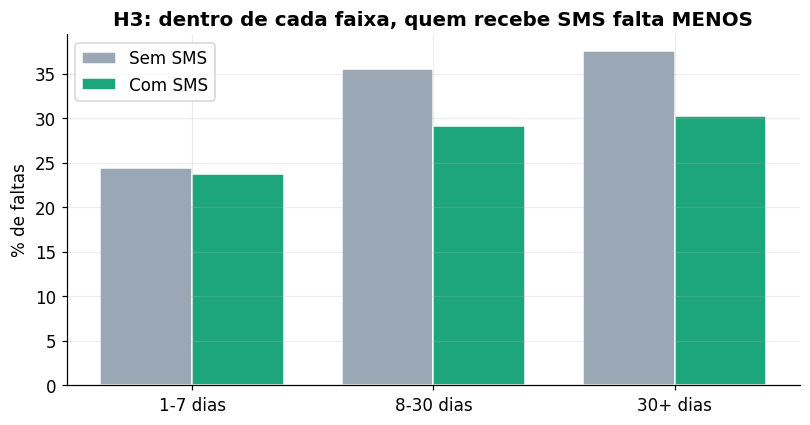

In [9]:
bruto = eda.groupby('SMS_received')['Faltou'].mean()*100
print(f"Comparacao BRUTA: sem SMS {bruto[0]:.1f}% de faltas | com SMS {bruto[1]:.1f}%  <- o SMS faz faltar?!")
print("NAO. O SMS so vai pra consulta agendada com antecedencia, que JA tem mais risco. E confundimento.")
print("A comparacao justa e DENTRO de cada faixa de espera:\n")
estrat = (eda[eda['FaixaEspera']!='Mesmo dia']
          .pivot_table(index='FaixaEspera', columns='SMS_received', values='Faltou', aggfunc='mean', observed=True)*100)
estrat.columns = ['Sem SMS (%)','Com SMS (%)']
print(estrat.round(1).to_string())

fig, ax = plt.subplots(figsize=(7.5,4))
x = np.arange(len(estrat)); w = 0.38
ax.bar(x-w/2, estrat['Sem SMS (%)'], w, label='Sem SMS', color='#9aa7b4', edgecolor='white')
ax.bar(x+w/2, estrat['Com SMS (%)'], w, label='Com SMS', color=TEAL, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(estrat.index.astype(str)); ax.set_ylabel('% de faltas'); ax.legend()
ax.set_title('H3: dentro de cada faixa, quem recebe SMS falta MENOS')
plt.tight_layout(); plt.show()

**📖 Como ler:** bruto, o SMS parece aumentar faltas. Estratificado, ele **reduz** (nas esperas longas, de ~37% pra ~30%). Lição de ouro pro TCC: *correlação bruta não é efeito; variáveis se entrelaçam.* Esse slide sozinho mostra maturidade.

## H4, H5 e H6 em uma célula


In [10]:
# H4: bairros (com minimo de 50 consultas, senao a taxa e ruido)
cont = eda['Neighbourhood'].value_counts(); validos = cont[cont >= 50].index
fb = eda[eda['Neighbourhood'].isin(validos)].groupby('Neighbourhood')['Faltou'].agg(['count','mean'])
top = (fb['mean']*100).sort_values(ascending=False).head(8)
print("H4: bairros com mais faltas (min. 50 consultas):"); print(top.round(1).to_string())
print(f"  -> varia de {(fb['mean']*100).min():.0f}% a {(fb['mean']*100).max():.0f}%: CONFIRMADA (geografia = acesso)")

# H5: sexo
ts = pd.crosstab(eda['Gender'], eda['Faltou']); chi_s, p_s, _, _ = chi2_contingency(ts)
tx = eda.groupby('Gender')['Faltou'].mean()*100
print(f"\nH5: mulheres {tx['F']:.1f}% vs homens {tx['M']:.1f}% | p = {p_s:.3f} -> DERRUBADA (e isso e resultado!)")
print("  mulheres sao 65% da base porque USAM mais o servico, nao porque faltam mais")

# H6: comorbidades
eda['QtdComorb'] = eda[['Hipertension','Diabetes','Alcoholism']].sum(axis=1) + (eda['Handcap']>0).astype(int)
tq = eda.groupby('QtdComorb')['Faltou'].agg(['count','mean']); tq['%'] = (tq['mean']*100).round(1)
print("\nH6: faltas por numero de comorbidades:"); print(tq[['count','%']].to_string())
print("  -> quem tem comorbidade falta um pouco MENOS. Repare o count: com 3-4, o grupo e minusculo, taxa instavel.")

H4: bairros com mais faltas (min. 50 consultas):
Neighbourhood
SANTOS DUMONT        28.9
SANTA CECÍLIA        27.5
SANTA CLARA          26.5
ITARARÉ              26.3
JESUS DE NAZARETH    24.4
HORTO                24.0
ILHA DO PRÍNCIPE     23.5
CARATOÍRA            23.0
  -> varia de 15% a 29%: CONFIRMADA (geografia = acesso)

H5: mulheres 20.3% vs homens 20.0% | p = 0.172 -> DERRUBADA (e isso e resultado!)
  mulheres sao 65% da base porque USAM mais o servico, nao porque faltam mais

H6: faltas por numero de comorbidades:
           count     %
QtdComorb             
0          84111  20.9
1          18121  17.9
2           7658  17.9
3            618  15.4
4             13  30.8
  -> quem tem comorbidade falta um pouco MENOS. Repare o count: com 3-4, o grupo e minusculo, taxa instavel.


**📖 Como ler:** H4 confirma a dimensão social (bairro é acesso); H5 cai e protege o modelo de um viés de gênero sem fundamento; H6 mostra a regra do `count`: taxa de grupo pequeno é ruído.

## A lista da faxina (o que a EDA mandou)

(1) renomear colunas com erro de grafia; (2) datas de texto pra data, só o dia; (3) criar `DiasEspera`, `FaixaEtaria`, `DiaSemana` (contas fixas); (4) derrubar idade negativa e espera negativa (6 linhas, preservadas à parte); (5) `Handcap` vira `TemDeficiencia` (0/1) e as comorbidades viram contagem; (6) derrubar os ids; (7) alvo `Faltou` 0/1. Nada calcula número da base: tudo pode vir antes de separar.


---
# Estação 5: FAXINA FIXA (a faxina da Tati, na base toda)

**🔎 O que vamos fazer:** aplicar a lista da EDA. Repare: cada item é regra ou conta fixa. **Nenhuma mediana, nenhuma escala**: isso é pra Estação 9, dentro do Pipeline.


In [11]:
limpo = base.rename(columns={'Hipertension':'Hypertension','Handcap':'Handicap','No-show':'NoShow'}).copy()
antes = len(limpo)

# datas: texto -> data, e so o DIA (AppointmentDay nao tem horario)
limpo['ScheduledDay'] = pd.to_datetime(limpo['ScheduledDay']).dt.normalize()
limpo['AppointmentDay'] = pd.to_datetime(limpo['AppointmentDay']).dt.normalize()

# contas fixas (nao aprendem nada da base)
limpo['DiasEspera'] = (limpo['AppointmentDay'] - limpo['ScheduledDay']).dt.days
limpo['DiaSemana'] = limpo['AppointmentDay'].dt.dayofweek.map({0:'Seg',1:'Ter',2:'Qua',3:'Qui',4:'Sex',5:'Sab',6:'Dom'})
limpo['FaixaEtaria'] = pd.cut(limpo['Age'], bins=[-1,12,17,39,59,200],
                              labels=['0-12','13-17','18-39','40-59','60+']).astype(str)
limpo['TemDeficiencia'] = (limpo['Handicap'] > 0).astype(int)
limpo['QtdComorbidades'] = limpo[['Hypertension','Diabetes','Alcoholism']].sum(axis=1) + limpo['TemDeficiencia']
limpo['Faltou'] = (limpo['NoShow'] == 'Yes').astype(int)

# erros de cadastro: removidos, mas PRESERVADOS (boa pratica da Tati)
erro = limpo[(limpo['Age'] < 0) | (limpo['DiasEspera'] < 0)]
erro.to_parquet('dados/02_registros_removidos.parquet', index=False)
limpo = limpo.drop(erro.index)

# identificadores e colunas ja usadas saem
limpo = limpo.drop(columns=['PatientId','AppointmentID','ScheduledDay','AppointmentDay','NoShow','Handicap'])

print(f"Linhas: {antes:,} -> {len(limpo):,} ({len(erro)} erros de cadastro removidos e guardados em dados/02_registros_removidos.parquet)")
print("Colunas finais:", list(limpo.columns))
limpo.to_parquet('dados/02_limpo.parquet', index=False)
print("Checkpoint 02_limpo salvo.")
limpo.head()

Linhas: 110,527 -> 110,521 (6 erros de cadastro removidos e guardados em dados/02_registros_removidos.parquet)
Colunas finais: ['Gender', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'SMS_received', 'DiasEspera', 'DiaSemana', 'FaixaEtaria', 'TemDeficiencia', 'QtdComorbidades', 'Faltou']
Checkpoint 02_limpo salvo.


,Gender,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,SMS_received,DiasEspera,DiaSemana,FaixaEtaria,TemDeficiencia,QtdComorbidades,Faltou
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,Sex,60+,0,1,0
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,Sex,40-59,0,0,0
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,Sex,60+,0,0,0
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,Sex,0-12,0,0,0
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,Sex,40-59,0,2,0


**📖 Como ler:** 6 linhas fora (0,005% da base), ids fora, datas viraram `DiasEspera` (a variável mais importante do projeto nasceu de uma CONTA), `Handicap` virou 0/1 honesto. E os removidos estão guardados: quem perguntar "o que vocês jogaram fora?" recebe um arquivo, não um "esqueci".


---
# Estação 6: SEPARAR TREINO E TESTE (com stratify: decisão consciente)

**🔎 O que vamos fazer:** 70% treino / 30% teste (a escolha de vocês), com `stratify=y` pra manter os 20% de faltas nos dois lados. Sem isso, o sorteio pode deixar o teste mais fácil ou mais difícil por acaso. O teste vira cofre 🔒 até a Estação 10.


In [12]:
X = limpo.drop(columns=['Faltou'])
y = limpo['Faltou']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
print("Treino:", X_tr.shape, "| Teste:", X_te.shape)
print(f"Faltas: {y_tr.mean()*100:.1f}% no treino | {y_te.mean()*100:.1f}% no teste  <- stratify funcionando")
X_tr.to_parquet('dados/03_X_treino.parquet'); X_te.to_parquet('dados/03_X_teste.parquet')
y_tr.to_frame().to_parquet('dados/03_y_treino.parquet'); y_te.to_frame().to_parquet('dados/03_y_teste.parquet')
print("Checkpoint 03 salvo.")

Treino: (77364, 13) | Teste: (33157, 13)
Faltas: 20.2% no treino | 20.2% no teste  <- stratify funcionando
Checkpoint 03 salvo.


---
# Estação 7: SELECIONAR VARIÁVEIS (só no treino!)

**🔎 O que vamos fazer:** montar a mesa: pra cada variável, quanto ela ajuda a prever a falta. Guia de bolso: numérica x alvo sim/não → `f_classif` (ANOVA) e informação mútua; categórica x alvo → chi2 + **V de Cramér** (a força, de 0 a 1). Tudo calculado NO TREINO (é um número aprendido dos dados).


In [13]:
c_num = ['Age','DiasEspera','QtdComorbidades','Scholarship','Hypertension','Diabetes','Alcoholism','TemDeficiencia','SMS_received']
c_cat = ['Gender','Neighbourhood','DiaSemana','FaixaEtaria']

f_scores = pd.Series(SelectKBest(f_classif, k='all').fit(X_tr[c_num], y_tr).scores_, index=c_num)
mi = pd.Series(mutual_info_classif(X_tr[c_num], y_tr, random_state=42), index=c_num)
mesa_num = pd.DataFrame({'f_classif (ANOVA)': f_scores.round(0), 'info_mutua': mi.round(4)}).sort_values('f_classif (ANOVA)', ascending=False)
print("MESA DAS NUMERICAS:"); print(mesa_num.to_string())

def cramers_v(x, y):
    tab = pd.crosstab(x, y); chi2, p, _, _ = chi2_contingency(tab)
    return np.sqrt(chi2/(tab.values.sum()*(min(tab.shape)-1))), p
print("\nMESA DAS CATEGORICAS (V de Cramer com o alvo):")
for c in c_cat:
    v, p = cramers_v(X_tr[c], y_tr)
    print(f"  {c:14s} V = {v:.3f}  (p = {p:.1e})")

MESA DAS NUMERICAS:
                 f_classif (ANOVA)  info_mutua
DiasEspera                  2669.0      0.0513
SMS_received                1279.0      0.0102
Age                          287.0      0.0025
Hypertension                  81.0      0.0012
Scholarship                   75.0      0.0010
QtdComorbidades               66.0      0.0021
Diabetes                      19.0      0.0018
TemDeficiencia                 7.0      0.0006
Alcoholism                     0.0      0.0007

MESA DAS CATEGORICAS (V de Cramer com o alvo):
  Gender         V = 0.008  (p = 3.6e-02)
  Neighbourhood  V = 0.071  (p = 1.6e-41)
  DiaSemana      V = 0.018  (p = 1.2e-04)
  FaixaEtaria    V = 0.081  (p = 3.0e-108)


**📖 Como ler:** `DiasEspera` esmaga todas (a H1 virou número). `SMS_received` aparece forte, mas lembrem: é força de ASSOCIAÇÃO, contaminada pelo confundimento; ela fica no modelo porque o modelo enxerga as duas juntas. `Gender` quase zero (a H5 derrubada aparece de novo). `Neighbourhood` tem V baixo, mas são 81 categorias com um sinal social real. **Decisão:** todas ficam, exceto `FaixaEtaria` (é a `Age` repetida em caixinhas: informação duplicada).


---
# Estação 8: A RÉGUA (antes de qualquer modelo)

**Os quatro destinos** de cada paciente: previu-compareceu e compareceu (VN, tudo certo); previu-falta mas compareceu (**FP, alarme falso**: uma ligação de confirmação a mais); previu-compareceu mas faltou (**FN, passou batido**: uma vaga desperdiçada e alguém sem atendimento); previu-falta e faltou (VP, o acerto que vale ouro).

$$\text{precisão} = \frac{VP}{VP+FP} \qquad \text{recall} = \frac{VP}{VP+FN} \qquad F1 = 2\cdot\frac{\text{precisão}\cdot\text{recall}}{\text{precisão}+\text{recall}}$$

**Lendo em português:** os dois têm o mesmo numerador (os acertos de falta); muda qual erro te preocupa. **Precisão:** "das que eu apontei como falta, quantas faltaram mesmo?" (custo do alarme falso). **Recall:** "das que faltaram de verdade, quantas eu achei?" (custo do passou-batido). No MedPredict, **recall manda**: alarme falso custa uma ligação; passou-batido custa uma consulta perdida.

**A armadilha da acurácia**, em números: o baseline que chuta "comparece" pra todo mundo faz 80% de acurácia e 0% de recall. A tabela da próxima estação prova.


---
# Estação 9: OS MODELOS

**🔎 O que vamos fazer:** o preparo dentro do Pipeline (mediana + escala nas numéricas, moda + one-hot nas categóricas: aprendido só no treino), 5 modelos, a tabela ordenada por F1 com o baseline no piso.


In [14]:
c_cat_modelo = ['Gender','Neighbourhood','DiaSemana']
preparo = ColumnTransformer([
    ('num', Pipeline([('preencher', SimpleImputer(strategy='median')), ('escala', StandardScaler())]), c_num),
    ('cat', Pipeline([('preencher', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), c_cat_modelo)])

modelos = {
    'Baseline (chuta comparece)': DummyClassifier(strategy='most_frequent'),
    'Regressao Logistica': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Arvore (rasa)': DecisionTreeClassifier(max_depth=5, min_samples_leaf=200, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_leaf=50,
                                            class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_depth=4,
                                                        class_weight='balanced', random_state=42),
}
linhas = []; fluxos = {}
for nome, m in modelos.items():
    fluxo = Pipeline([('preparo', preparo), ('modelo', m)]).fit(X_tr, y_tr)
    fluxos[nome] = fluxo
    p = fluxo.predict(X_te)
    linhas.append({'modelo':nome, 'acuracia':round(accuracy_score(y_te,p),3),
                   'precisao_faltou':round(precision_score(y_te,p,zero_division=0),3),
                   'recall_faltou':round(recall_score(y_te,p,zero_division=0),3),
                   'F1_faltou':round(f1_score(y_te,p,zero_division=0),3)})
tab = pd.DataFrame(linhas).sort_values('F1_faltou', ascending=False).reset_index(drop=True)
tab

,modelo,acuracia,precisao_faltou,recall_faltou,F1_faltou
0,Gradient Boosting,0.578,0.303,0.840,0.446
1,Arvore (rasa),0.562,0.297,0.853,0.440
2,Random Forest,0.572,0.298,0.825,0.437
3,Regressao Logistica,0.654,0.308,0.576,0.402
4,Baseline (chuta comparece),0.798,0.000,0.000,0.000


**📖 Como ler:** primeira linha a olhar é a do **baseline**: acurácia ~0.80 e recall 0. A armadilha, provada. Os modelos com `class_weight='balanced'` derrubam a acurácia de propósito (aceitam alarmes falsos) pra subir o recall. F1 ordena. E os números modestos são honestos: **faltar é um comportamento humano que a base descreve pouco** (não sabe se choveu, se o ônibus atrasou, se a pessoa melhorou). O modelo é útil pra PRIORIZAR ligações, não pra adivinhar.

## O campeão e os quatro destinos


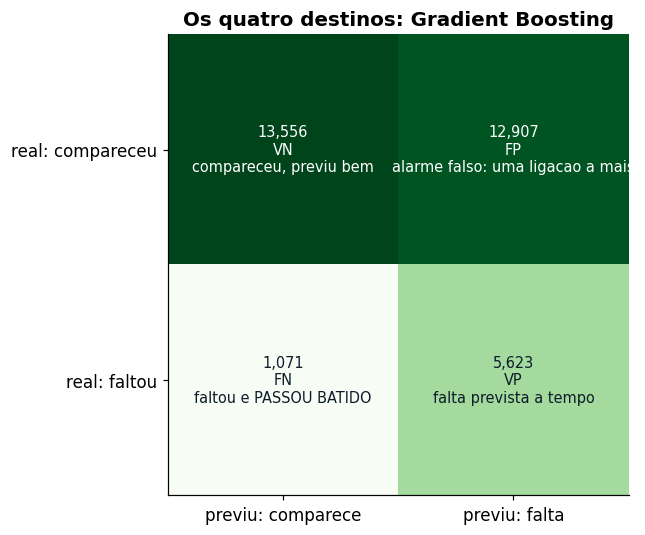

Campeao por F1: Gradient Boosting | recall 0.840: de cada 100 faltas reais, encontra 84


In [15]:
campeao_nome = tab.iloc[0]['modelo']
campeao = fluxos[campeao_nome]
p = campeao.predict(X_te)
cm = confusion_matrix(y_te, p)
fig, ax = plt.subplots(figsize=(6,5))
ax.imshow(cm, cmap='Greens'); ax.grid(False)
rot = [['VN\ncompareceu, previu bem','FP\nalarme falso: uma ligacao a mais'],
       ['FN\nfaltou e PASSOU BATIDO','VP\nfalta prevista a tempo']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}\n{rot[i][j]}", ha='center', va='center', fontsize=9.5,
                color='white' if cm[i,j] > cm.max()/2 else NAVY)
ax.set_xticks([0,1]); ax.set_xticklabels(['previu: comparece','previu: falta'])
ax.set_yticks([0,1]); ax.set_yticklabels(['real: compareceu','real: faltou'])
ax.set_title(f'Os quatro destinos: {campeao_nome}')
plt.tight_layout(); plt.show()
print(f"Campeao por F1: {campeao_nome} | recall {recall_score(y_te,p):.3f}: de cada 100 faltas reais, encontra {recall_score(y_te,p)*100:.0f}")

---
# Estação 10: O LIMIAR, o AJUSTE e o MODELO SALVO

## A estrela do grupo: o limiar de decisão (o dimmer, não o interruptor)

**🔎 O que vamos fazer:** o modelo não decide "falta/não falta": ele dá uma **probabilidade**, e o corte padrão é 0.50. Baixar o corte é dizer "qualquer sinal de risco já vale uma ligação": sobe o recall, desce a precisão. A escolha certa depende do CUSTO de cada erro na clínica. E o teste continua no cofre: testamos limiares com previsões de validação cruzada **no treino** (`cross_val_predict`).


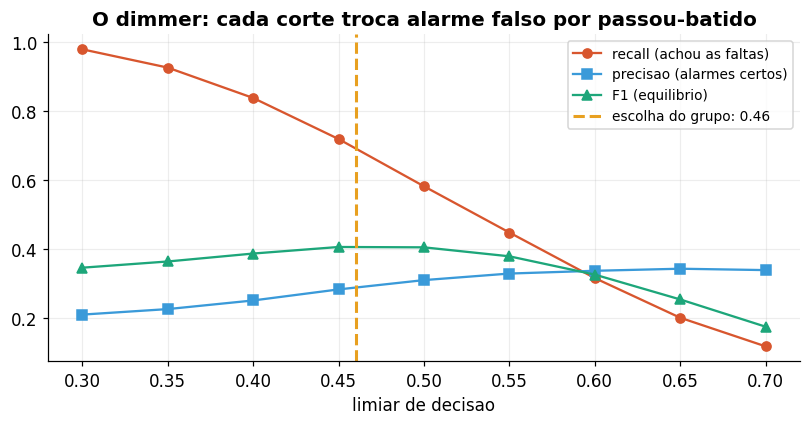

 limiar  precisao  recall    F1
   0.30     0.210   0.979 0.346
   0.35     0.226   0.926 0.364
   0.40     0.251   0.838 0.387
   0.45     0.283   0.719 0.406
   0.50     0.310   0.582 0.405
   0.55     0.329   0.448 0.379
   0.60     0.337   0.316 0.326
   0.65     0.343   0.201 0.254
   0.70     0.339   0.118 0.175


In [16]:
logit = fluxos['Regressao Logistica']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
prob_cv = cross_val_predict(logit, X_tr, y_tr, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

linhas = []
for t in np.arange(0.30, 0.71, 0.05):
    pt = (prob_cv >= t).astype(int)
    linhas.append({'limiar':round(t,2), 'precisao':round(precision_score(y_tr,pt),3),
                   'recall':round(recall_score(y_tr,pt),3), 'F1':round(f1_score(y_tr,pt),3)})
mesa_limiar = pd.DataFrame(linhas)
fig, ax = plt.subplots(figsize=(7.5,4))
ax.plot(mesa_limiar['limiar'], mesa_limiar['recall'], 'o-', color=CORAL, label='recall (achou as faltas)')
ax.plot(mesa_limiar['limiar'], mesa_limiar['precisao'], 's-', color=SKY, label='precisao (alarmes certos)')
ax.plot(mesa_limiar['limiar'], mesa_limiar['F1'], '^-', color=TEAL, label='F1 (equilibrio)')
ax.axvline(0.46, color=AMBER, linestyle='--', linewidth=2, label='escolha do grupo: 0.46')
ax.set_xlabel('limiar de decisao'); ax.set_title('O dimmer: cada corte troca alarme falso por passou-batido'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(mesa_limiar.to_string(index=False))

**📖 Como ler:** com corte 0.30 o recall vai a ~1.0 (acha todas as faltas) mas a precisão despenca (liga pra todo mundo). Com 0.70 quase não liga. O grupo escolheu **0.46**, onde o F1 fica no topo e o recall passa de ~58% pra ~69%. **A frase pro TCC:** "escolhemos o limiar olhando o custo de cada erro: uma ligação a mais é barata, uma consulta perdida é cara".

## GridSearch (validação cruzada, no treino) e a prova final no teste

**Uma decisão pra defender na banca:** na tabela da Estação 9, o Gradient Boosting ficou na frente por F1 (com recall ainda maior). O grupo escolheu a **Regressão Logística** por dois motivos legítimos: a diferença é pequena e **ela explica** (os coeficientes abaixo dizem o que empurra pra falta). Modelo que a gestão entende vale mais que dois pontos de F1. Levem os dois pra mentoria e decidam com o argumento na mão.


In [17]:
fluxo_lr = Pipeline([('preparo', preparo), ('modelo', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))])
grade = {'modelo__C': [0.01, 0.1, 1.0, 10.0]}
busca = GridSearchCV(fluxo_lr, grade, cv=cv, scoring='f1', n_jobs=-1)
busca.fit(X_tr, y_tr)
print("Melhor C:", busca.best_params_, f"| F1 na validacao cruzada: {busca.best_score_:.3f}")

LIMIAR = 0.46
prob_te = busca.best_estimator_.predict_proba(X_te)[:, 1]
p_final = (prob_te >= LIMIAR).astype(int)
cm = confusion_matrix(y_te, p_final)
print(f"\nPROVA FINAL (teste, UMA vez, limiar {LIMIAR}):")
print(f"  recall {recall_score(y_te,p_final):.3f} | precisao {precision_score(y_te,p_final):.3f} | F1 {f1_score(y_te,p_final):.3f}")
print(f"  faltas reais no teste: {cm[1].sum():,} | detectadas: {cm[1,1]:,} | passaram batido: {cm[1,0]:,}")
print(f"  alarmes falsos: {cm[0,1]:,} (ligacoes 'a toa', o preco de nao deixar passar)")

Melhor C: {'modelo__C': 0.01} | F1 na validacao cruzada: 0.406

PROVA FINAL (teste, UMA vez, limiar 0.46):
  recall 0.682 | precisao 0.291 | F1 0.408
  faltas reais no teste: 6,694 | detectadas: 4,566 | passaram batido: 2,128
  alarmes falsos: 11,125 (ligacoes 'a toa', o preco de nao deixar passar)


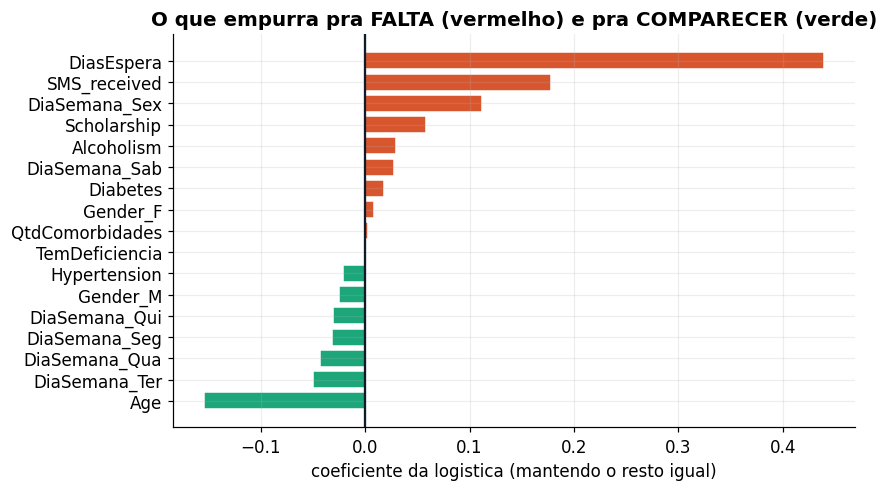

Leitura: DiasEspera e o maior empurrao pra falta (H1 quantificada). Idade empurra pra comparecer (idosos faltam menos).
Os bairros ficaram fora do grafico so pra caber: sao 81 barras.


In [18]:
# quem mais pesa: os coeficientes da logistica (a estrela interpretavel)
nomes = busca.best_estimator_.named_steps['preparo'].get_feature_names_out()
coefs = pd.Series(busca.best_estimator_.named_steps['modelo'].coef_[0], index=nomes)
sel = coefs[[n for n in coefs.index if 'Neighbourhood' not in n]].sort_values()
fig, ax = plt.subplots(figsize=(8,4.6))
ax.barh([n.replace('num__','').replace('cat__','') for n in sel.index], sel.values,
        color=[CORAL if v>0 else TEAL for v in sel.values], edgecolor='white')
ax.axvline(0, color=NAVY, linewidth=1.5)
ax.set_title('O que empurra pra FALTA (vermelho) e pra COMPARECER (verde)')
ax.set_xlabel('coeficiente da logistica (mantendo o resto igual)')
plt.tight_layout(); plt.show()
print("Leitura: DiasEspera e o maior empurrao pra falta (H1 quantificada). Idade empurra pra comparecer (idosos faltam menos).")
print("Os bairros ficaram fora do grafico so pra caber: sao 81 barras.")

In [19]:
import joblib
joblib.dump({'modelo': busca.best_estimator_, 'limiar': LIMIAR}, 'dados/medpredict_final.joblib')
pacote = joblib.load('dados/medpredict_final.joblib')

# prova com pacientes novos: dois iguais em tudo, diferentes SO na espera
paciente = {'Age':28,'QtdComorbidades':0,'Scholarship':0,'Hypertension':0,'Diabetes':0,'Alcoholism':0,
            'TemDeficiencia':0,'SMS_received':1,'Gender':'F','Neighbourhood':'JARDIM DA PENHA','DiaSemana':'Ter'}
novos = pd.DataFrame([{**paciente,'DiasEspera':0}, {**paciente,'DiasEspera':25}])
prob = pacote['modelo'].predict_proba(novos)[:,1]
for d, pr in zip([0,25], prob):
    print(f"paciente igual, espera de {d:2d} dias -> risco de falta {pr*100:.0f}% -> {'LIGAR pra confirmar' if pr >= pacote['limiar'] else 'sem alerta'}")
print("\nModelo + limiar salvos em dados/medpredict_final.joblib: o cerebro pronto pra camada de IA da mentoria.")

paciente igual, espera de  0 dias -> risco de falta 43% -> sem alerta
paciente igual, espera de 25 dias -> risco de falta 60% -> LIGAR pra confirmar

Modelo + limiar salvos em dados/medpredict_final.joblib: o cerebro pronto pra camada de IA da mentoria.


---
# ✅ O CHECKLIST DO MEDPREDICT

1. **Carga com ritual** (shape/head/info) e checkpoint em parquet.
2. **6 hipóteses** com afirmação + mecanismo + teste; H5 derrubada e registrada como resultado.
3. **EDA que enxergou a sujeira sem vazio** (idade negativa, datas sem horário, Handcap 0-4) e **o confundimento do SMS** (a estrela da leitura crítica).
4. **Faxina fixa** com regras e contas (nada de mediana antes do split), removidos preservados em arquivo.
5. **Separação com stratify** (alvo 80/20) e o teste no cofre.
6. **Mesa de seleção** no treino: ANOVA, informação mútua, V de Cramér; `FaixaEtaria` fora por repetir `Age`.
7. **A régua antes dos modelos:** quatro destinos, acurácia desmascarada, recall como métrica do problema.
8. **5 modelos com o baseline no piso**, matriz dos quatro destinos, leitura honesta dos números modestos.
9. **O limiar como dimmer** (0.46, escolhido no treino com validação cruzada), GridSearch, prova final UMA vez.
10. **Modelo salvo com o limiar dentro** e a prova dos dois pacientes iguais que só diferem na espera.

**Pra mentoria e pra camada de IA:** o produto é uma lista diária "quem ligar hoje pra confirmar" pra recepção da clínica, com a mensagem gerada pela IA a partir do risco e do motivo (espera longa, bairro, histórico). O modelo prioriza; a pessoa decide e liga. 💛
